In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import ast
import warnings
warnings.filterwarnings("ignore")


In [2]:

# =============================================================================
# STEP 1: Load Data
# =============================================================================

print("="*60)
print("STEP 1: Loading Data")
print("="*60)

db = pd.read_csv("../ptb-xl/ptbxl_database.csv")
scp = pd.read_csv("../ptb-xl/scp_statements.csv", index_col=0)
features = pd.read_csv("../ptb-xl+/features/12sl_features.csv")

print(f"  Metadata: {db.shape}")
print(f"  Features: {features.shape}")


STEP 1: Loading Data
  Metadata: (21799, 28)
  Features: (21799, 783)


In [3]:

# =============================================================================
# STEP 2: Create Labels
# =============================================================================

print("\n" + "="*60)
print("STEP 2: Creating Labels")
print("="*60)

db["scp_codes"] = db["scp_codes"].apply(ast.literal_eval)
scp_diag = scp[scp["diagnostic"] == 1]

def get_diagnostic_superclass(codes_dict):
    for code in codes_dict.keys():
        if code in scp_diag.index:
            return scp_diag.loc[code, "diagnostic_class"]
    return None

db["label"] = db["scp_codes"].apply(get_diagnostic_superclass)

# Merge features with labels and metadata
df = features.merge(
    db[["ecg_id", "label", "strat_fold", "age", "sex", "height", "weight"]], 
    on="ecg_id", 
    how="left"
)

print(f"  Merged shape: {df.shape}")
df[:5]  # Display first 5 rows


STEP 2: Creating Labels
  Merged shape: (21799, 789)


,P_Area_I,P_PeakTime_I,Q_Area_I,Q_PeakTime_I,R_Area_I,R_PeakTime_I,S_Area_I,S_PeakTime_I,QRS_Balance_I,T_Area_I,...,P_Dur_Global,P_Found_Global,HR__Global,P_Term_V1,label,strat_fold,age,sex,height,weight
0,0.264,64.0,0.000,0.0,0.737,30.0,0.000,0.0,629.0,0.819,...,112.0,1,64.0,0.000,NORM,3,56.0,1,NaN,63.0
1,-0.047,6.0,0.015,8.0,0.794,36.0,1.246,76.0,205.0,2.206,...,66.0,1,75.0,0.000,CD,2,87.0,1,NaN,NaN
2,0.000,0.0,0.000,0.0,0.792,38.0,1.389,74.0,141.0,1.155,...,NaN,0,169.0,0.000,CD,2,87.0,1,NaN,NaN
3,0.196,74.0,0.000,0.0,0.947,56.0,0.000,0.0,439.0,-0.339,...,114.0,1,79.0,0.000,MI,3,72.0,0,NaN,NaN
4,0.287,102.0,0.000,0.0,1.021,36.0,0.000,0.0,937.0,0.756,...,136.0,1,92.0,6.612,STTC,5,85.0,0,NaN,NaN


In [4]:

# =============================================================================
# STEP 3: Remove rows with missing labels
# =============================================================================

print("\n" + "="*60)
print("STEP 3: Removing Rows with Missing Labels")
print("="*60)

before = len(df)
df = df.dropna(subset=["label"])
after = len(df)

print(f"  Removed: {before - after} rows ({(before-after)/before*100:.2f}%)")
print(f"  Remaining: {after} rows")



STEP 3: Removing Rows with Missing Labels
  Removed: 411 rows (1.89%)
  Remaining: 21388 rows


In [5]:

# =============================================================================
# STEP 4: Row-wise missing pattern analysis
# =============================================================================

print("\n" + "="*60)
print("STEP 4: Row-wise Missing Pattern Analysis")
print("="*60)

# Calculate missing ratio per row
exclude_cols = ["ecg_id", "label", "strat_fold", "age", "sex", "height", "weight"]
feature_cols_temp = [col for col in df.columns if col not in exclude_cols]

row_missing = df[feature_cols_temp].isnull().sum(axis=1)
row_missing_ratio = row_missing / len(feature_cols_temp)

print(f"  Max missing ratio per row: {row_missing_ratio.max():.2%}")
print(f"  Rows with >50% missing: {(row_missing_ratio > 0.5).sum()}")
print(f"  Rows with >25% missing: {(row_missing_ratio > 0.25).sum()}")
print(f"  Rows with >10% missing: {(row_missing_ratio > 0.1).sum()}")

# Remove rows with >50% missing features (if any)
high_missing_mask = row_missing_ratio > 0.5
if high_missing_mask.sum() > 0:
    print(f"  Removing {high_missing_mask.sum()} rows with >50% missing features")
    df = df[~high_missing_mask]
else:
    print("  No rows with >50% missing features - keeping all")



STEP 4: Row-wise Missing Pattern Analysis
  Max missing ratio per row: 0.90%
  Rows with >50% missing: 0
  Rows with >25% missing: 0
  Rows with >10% missing: 0
  No rows with >50% missing features - keeping all


In [6]:

# =============================================================================
# STEP 5: Create BMI feature from height/weight
# =============================================================================

print("\n" + "="*60)
print("STEP 5: Feature Engineering - BMI")
print("="*60)

# BMI = weight (kg) / (height (cm) / 100)^2
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

print(f"  BMI created: mean={df['BMI'].mean():.2f}, missing={df['BMI'].isnull().sum()}")
print(f"  Height missing: {df['height'].isnull().sum()}")
print(f"  Weight missing: {df['weight'].isnull().sum()}")



STEP 5: Feature Engineering - BMI
  BMI created: mean=25.23, missing=14693
  Height missing: 14470
  Weight missing: 12022


In [7]:

# =============================================================================
# STEP 6: Create Missing Indicator Features (Hybrid Approach)
# =============================================================================

print("\n" + "="*60)
print("STEP 6: Creating Missing Indicator Features")
print("="*60)

# These features have clinically meaningful missingness
# P wave missing = likely AF, flutter, junctional rhythm
clinical_missing_features = [
    "P_On_Global",
    "P_Off_Global", 
    "P_Dur_Global",
    "PR_Int_Global",
    "P_AxisFront_Global",
    "HR_Atrial_Global"
]

# Create binary missing indicators
for feat in clinical_missing_features:
    if feat in df.columns:
        missing_col = f"{feat}_missing"
        df[missing_col] = df[feat].isnull().astype(int)
        print(f"  Created {missing_col}: {df[missing_col].sum()} missing ({df[missing_col].mean()*100:.2f}%)")



STEP 6: Creating Missing Indicator Features
  Created P_On_Global_missing: 1763 missing (8.24%)
  Created P_Off_Global_missing: 1763 missing (8.24%)
  Created P_Dur_Global_missing: 1763 missing (8.24%)
  Created PR_Int_Global_missing: 1722 missing (8.05%)
  Created P_AxisFront_Global_missing: 1740 missing (8.14%)
  Created HR_Atrial_Global_missing: 1507 missing (7.05%)


In [8]:

# =============================================================================
# STEP 7: Define feature groups
# =============================================================================

print("\n" + "="*60)
print("STEP 7: Defining Feature Groups")
print("="*60)

# Columns to exclude from features
meta_cols = ["ecg_id", "label", "strat_fold"]

# Clinical features from PTB-XL+ (will be imputed)
feature_cols = [col for col in df.columns 
                if col not in meta_cols 
                and not col.endswith("_missing")]

# Missing indicator features (no imputation needed)
missing_indicator_cols = [col for col in df.columns if col.endswith("_missing")]

print(f"  Numeric features: {len(feature_cols)}")
print(f"  Missing indicators: {len(missing_indicator_cols)}")
print(f"  Total features: {len(feature_cols) + len(missing_indicator_cols)}")



STEP 7: Defining Feature Groups
  Numeric features: 787
  Missing indicators: 6
  Total features: 793


In [9]:

# =============================================================================
# STEP 8: Train/Val/Test Split (BEFORE imputation - critical!)
# =============================================================================

print("\n" + "="*60)
print("STEP 8: Train/Val/Test Split (Before Imputation)")
print("="*60)

# PTB-XL predefined folds: 1-8 = train, 9 = val, 10 = test
train_mask = df["strat_fold"] <= 8
val_mask = df["strat_fold"] == 9
test_mask = df["strat_fold"] == 10

df_train = df[train_mask].copy()
df_val = df[val_mask].copy()
df_test = df[test_mask].copy()

print(f"  Train: {len(df_train)} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val)} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test)} samples ({len(df_test)/len(df)*100:.1f}%)")

# Separate X and y
X_train = df_train[feature_cols]
X_val = df_val[feature_cols]
X_test = df_test[feature_cols]

y_train = df_train["label"]
y_val = df_val["label"]
y_test = df_test["label"]

# Missing indicators (no imputation needed)
X_train_missing = df_train[missing_indicator_cols]
X_val_missing = df_val[missing_indicator_cols]
X_test_missing = df_test[missing_indicator_cols]



STEP 8: Train/Val/Test Split (Before Imputation)
  Train: 17084 samples (79.9%)
  Val:   2146 samples (10.0%)
  Test:  2158 samples (10.1%)


In [10]:

# =============================================================================
# STEP 9: Imputation - FIT ONLY ON TRAIN SET (No Data Leakage!)
# =============================================================================

print("\n" + "="*60)
print("STEP 9: Imputation (Train-only fit - No Data Leakage)")
print("="*60)

# Check missing before
print(f"  Missing values before imputation:")
print(f"    Train: {X_train.isnull().sum().sum()}")
print(f"    Val:   {X_val.isnull().sum().sum()}")
print(f"    Test:  {X_test.isnull().sum().sum()}")

# Fit imputer ONLY on train set
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)  # FIT only on train!

# Transform all sets
X_train_imputed = pd.DataFrame(
    imputer.transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val),
    columns=feature_cols,
    index=X_val.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"\n  Missing values after imputation:")
print(f"    Train: {X_train_imputed.isnull().sum().sum()}")
print(f"    Val:   {X_val_imputed.isnull().sum().sum()}")
print(f"    Test:  {X_test_imputed.isnull().sum().sum()}")



STEP 9: Imputation (Train-only fit - No Data Leakage)
  Missing values before imputation:
    Train: 41455
    Val:   4974
    Test:  5019

  Missing values after imputation:
    Train: 0
    Val:   0
    Test:  0


In [11]:

# =============================================================================
# STEP 10: Feature Scaling - FIT ONLY ON TRAIN SET
# =============================================================================

print("\n" + "="*60)
print("STEP 10: Feature Scaling (Train-only fit)")
print("="*60)

scaler = StandardScaler()
scaler.fit(X_train_imputed)  # FIT only on train!

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imputed),
    columns=feature_cols,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed),
    columns=feature_cols,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=feature_cols,
    index=X_test.index
)

print(f"  Train mean: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"  Train std:  {X_train_scaled.std().mean():.6f} (should be ~1)")
print(f"  Val mean:   {X_val_scaled.mean().mean():.6f} (slightly off is OK)")
print(f"  Test mean:  {X_test_scaled.mean().mean():.6f} (slightly off is OK)")



STEP 10: Feature Scaling (Train-only fit)
  Train mean: -0.000000 (should be ~0)
  Train std:  1.000029 (should be ~1)
  Val mean:   -0.002029 (slightly off is OK)
  Test mean:  0.000312 (slightly off is OK)


In [12]:

# =============================================================================
# STEP 11: Combine scaled features with missing indicators
# =============================================================================

print("\n" + "="*60)
print("STEP 11: Combining Features with Missing Indicators")
print("="*60)

X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_missing.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_missing.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_missing.reset_index(drop=True)], axis=1)

print(f"  Final feature count: {X_train_final.shape[1]}")
print(f"    - Numeric features: {len(feature_cols)}")
print(f"    - Missing indicators: {len(missing_indicator_cols)}")



STEP 11: Combining Features with Missing Indicators
  Final feature count: 793
    - Numeric features: 787
    - Missing indicators: 6


In [13]:

# =============================================================================
# STEP 12: Class Distribution & Weights
# =============================================================================

print("\n" + "="*60)
print("STEP 12: Class Distribution & Weights")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight

print("  Class distribution in each split:")
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = y.value_counts()
    print(f"\n  {name}:")
    for cls in sorted(counts.index):
        print(f"    {cls}: {counts[cls]} ({counts[cls]/len(y)*100:.1f}%)")

# Compute class weights from train set only
classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("\n  Class weights (computed from train):")
for cls, weight in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"    {cls}: {weight:.3f}")



STEP 12: Class Distribution & Weights
  Class distribution in each split:

  Train:
    CD: 1842 (10.8%)
    HYP: 1057 (6.2%)
    MI: 4345 (25.4%)
    NORM: 7596 (44.5%)
    STTC: 2244 (13.1%)

  Val:
    CD: 238 (11.1%)
    HYP: 129 (6.0%)
    MI: 535 (24.9%)
    NORM: 955 (44.5%)
    STTC: 289 (13.5%)

  Test:
    CD: 245 (11.4%)
    HYP: 122 (5.7%)
    MI: 544 (25.2%)
    NORM: 963 (44.6%)
    STTC: 284 (13.2%)

  Class weights (computed from train):
    HYP: 3.233
    CD: 1.855
    STTC: 1.523
    MI: 0.786
    NORM: 0.450


In [14]:

# =============================================================================
# STEP 13: Save preprocessed data
# =============================================================================

print("\n" + "="*60)
print("STEP 13: Saving Preprocessed Data")
print("="*60)

import os
os.makedirs("../data/processed", exist_ok=True)

# Save as CSV
X_train_final.to_csv("../data/processed/X_train.csv", index=False)
X_val_final.to_csv("../data/processed/X_val.csv", index=False)
X_test_final.to_csv("../data/processed/X_test.csv", index=False)

y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

# Save class weights
pd.DataFrame([class_weight_dict]).to_csv("../data/processed/class_weights.csv", index=False)

# Save feature names
all_features = list(feature_cols) + list(missing_indicator_cols)
pd.DataFrame({"feature": all_features}).to_csv("../data/processed/feature_names.csv", index=False)

print("  Files saved to ../data/processed/")



STEP 13: Saving Preprocessed Data
  Files saved to ../data/processed/


In [15]:

# =============================================================================
# STEP 14: Summary
# =============================================================================

print("\n" + "="*60)
print("PREPROCESSING COMPLETE - SUMMARY")
print("="*60)
print(f"""
Dataset:
  - Total samples: {len(df)}
  - Features: {len(all_features)} ({len(feature_cols)} numeric + {len(missing_indicator_cols)} missing indicators)
  - Classes: {len(classes)} ({', '.join(sorted(classes))})

Splits:
  - Train: {len(X_train_final)} ({len(X_train_final)/len(df)*100:.1f}%)
  - Val:   {len(X_val_final)} ({len(X_val_final)/len(df)*100:.1f}%)
  - Test:  {len(X_test_final)} ({len(X_test_final)/len(df)*100:.1f}%)

Preprocessing Steps:
  1. Removed rows with missing labels (411 rows)
  2. Row-wise missing check (removed rows with >50% missing)
  3. Created BMI feature from height/weight
  4. Created missing indicator features for P-wave related columns
  5. Train/Val/Test split BEFORE imputation (no data leakage)
  6. Median imputation (fitted on train only)
  7. StandardScaler (fitted on train only)
  8. Computed class weights for imbalance handling

Missing Indicators Created:
  {', '.join(missing_indicator_cols)}

Class Weights:
  {', '.join([f'{k}: {v:.2f}' for k, v in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)])}
""")

# Create binary missing indicators
for feat in clinical_missing_features:
    if feat in df.columns:
        missing_col = f"{feat}_missing"
        df[missing_col] = df[feat].isnull().astype(int)
        print(f"  Created {missing_col}: {df[missing_col].sum()} missing ({df[missing_col].mean()*100:.2f}%)")



PREPROCESSING COMPLETE - SUMMARY

Dataset:
  - Total samples: 21388
  - Features: 793 (787 numeric + 6 missing indicators)
  - Classes: 5 (CD, HYP, MI, NORM, STTC)

Splits:
  - Train: 17084 (79.9%)
  - Val:   2146 (10.0%)
  - Test:  2158 (10.1%)

Preprocessing Steps:
  1. Removed rows with missing labels (411 rows)
  2. Row-wise missing check (removed rows with >50% missing)
  3. Created BMI feature from height/weight
  4. Created missing indicator features for P-wave related columns
  5. Train/Val/Test split BEFORE imputation (no data leakage)
  6. Median imputation (fitted on train only)
  7. StandardScaler (fitted on train only)
  8. Computed class weights for imbalance handling

Missing Indicators Created:
  P_On_Global_missing, P_Off_Global_missing, P_Dur_Global_missing, PR_Int_Global_missing, P_AxisFront_Global_missing, HR_Atrial_Global_missing

Class Weights:
  HYP: 3.23, CD: 1.85, STTC: 1.52, MI: 0.79, NORM: 0.45

  Created P_On_Global_missing: 1763 missing (8.24%)
  Created P

In [16]:

# =============================================================================
# STEP 7: Define feature groups
# =============================================================================

print("\n" + "="*60)
print("STEP 7: Defining Feature Groups")
print("="*60)

# Columns to exclude from features
meta_cols = ["ecg_id", "label", "strat_fold"]

# Clinical features from PTB-XL+ (will be imputed)
feature_cols = [col for col in df.columns 
                if col not in meta_cols 
                and not col.endswith("_missing")]

# Missing indicator features (no imputation needed)
missing_indicator_cols = [col for col in df.columns if col.endswith("_missing")]

print(f"  Numeric features: {len(feature_cols)}")
print(f"  Missing indicators: {len(missing_indicator_cols)}")
print(f"  Total features: {len(feature_cols) + len(missing_indicator_cols)}")



STEP 7: Defining Feature Groups
  Numeric features: 787
  Missing indicators: 6
  Total features: 793


In [17]:

# =============================================================================
# STEP 8: Train/Val/Test Split (BEFORE imputation - critical!)
# =============================================================================

print("\n" + "="*60)
print("STEP 8: Train/Val/Test Split (Before Imputation)")
print("="*60)

# PTB-XL predefined folds: 1-8 = train, 9 = val, 10 = test
train_mask = df["strat_fold"] <= 8
val_mask = df["strat_fold"] == 9
test_mask = df["strat_fold"] == 10

df_train = df[train_mask].copy()
df_val = df[val_mask].copy()
df_test = df[test_mask].copy()

print(f"  Train: {len(df_train)} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val)} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test)} samples ({len(df_test)/len(df)*100:.1f}%)")

# Separate X and y
X_train = df_train[feature_cols]
X_val = df_val[feature_cols]
X_test = df_test[feature_cols]

y_train = df_train["label"]
y_val = df_val["label"]
y_test = df_test["label"]

# Missing indicators (no imputation needed)
X_train_missing = df_train[missing_indicator_cols]
X_val_missing = df_val[missing_indicator_cols]
X_test_missing = df_test[missing_indicator_cols]



STEP 8: Train/Val/Test Split (Before Imputation)
  Train: 17084 samples (79.9%)
  Val:   2146 samples (10.0%)
  Test:  2158 samples (10.1%)


In [18]:

# =============================================================================
# STEP 9: Imputation - FIT ONLY ON TRAIN SET (No Data Leakage!)
# =============================================================================

print("\n" + "="*60)
print("STEP 9: Imputation (Train-only fit - No Data Leakage)")
print("="*60)

# Check missing before
print(f"  Missing values before imputation:")
print(f"    Train: {X_train.isnull().sum().sum()}")
print(f"    Val:   {X_val.isnull().sum().sum()}")
print(f"    Test:  {X_test.isnull().sum().sum()}")

# Fit imputer ONLY on train set
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)  # FIT only on train!

# Transform all sets
X_train_imputed = pd.DataFrame(
    imputer.transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val),
    columns=feature_cols,
    index=X_val.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print(f"\n  Missing values after imputation:")
print(f"    Train: {X_train_imputed.isnull().sum().sum()}")
print(f"    Val:   {X_val_imputed.isnull().sum().sum()}")
print(f"    Test:  {X_test_imputed.isnull().sum().sum()}")



STEP 9: Imputation (Train-only fit - No Data Leakage)
  Missing values before imputation:
    Train: 41455
    Val:   4974
    Test:  5019

  Missing values after imputation:
    Train: 0
    Val:   0
    Test:  0


In [19]:

# =============================================================================
# STEP 10: Feature Scaling - FIT ONLY ON TRAIN SET
# =============================================================================

print("\n" + "="*60)
print("STEP 10: Feature Scaling (Train-only fit)")
print("="*60)

scaler = StandardScaler()
scaler.fit(X_train_imputed)  # FIT only on train!

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_imputed),
    columns=feature_cols,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_imputed),
    columns=feature_cols,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=feature_cols,
    index=X_test.index
)

print(f"  Train mean: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"  Train std:  {X_train_scaled.std().mean():.6f} (should be ~1)")
print(f"  Val mean:   {X_val_scaled.mean().mean():.6f} (slightly off is OK)")
print(f"  Test mean:  {X_test_scaled.mean().mean():.6f} (slightly off is OK)")



STEP 10: Feature Scaling (Train-only fit)
  Train mean: -0.000000 (should be ~0)
  Train std:  1.000029 (should be ~1)
  Val mean:   -0.002029 (slightly off is OK)
  Test mean:  0.000312 (slightly off is OK)


In [20]:

# =============================================================================
# STEP 11: Combine scaled features with missing indicators
# =============================================================================

print("\n" + "="*60)
print("STEP 11: Combining Features with Missing Indicators")
print("="*60)

X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_missing.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_missing.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_missing.reset_index(drop=True)], axis=1)

print(f"  Final feature count: {X_train_final.shape[1]}")
print(f"    - Numeric features: {len(feature_cols)}")
print(f"    - Missing indicators: {len(missing_indicator_cols)}")



STEP 11: Combining Features with Missing Indicators
  Final feature count: 793
    - Numeric features: 787
    - Missing indicators: 6



STEP 12: Class Distribution & Weights
  Class distribution in each split:

  Train:
    CD: 1842 (10.8%)
    HYP: 1057 (6.2%)
    MI: 4345 (25.4%)
    NORM: 7596 (44.5%)
    STTC: 2244 (13.1%)

  Val:
    CD: 238 (11.1%)
    HYP: 129 (6.0%)
    MI: 535 (24.9%)
    NORM: 955 (44.5%)
    STTC: 289 (13.5%)

  Test:
    CD: 245 (11.4%)
    HYP: 122 (5.7%)
    MI: 544 (25.2%)
    NORM: 963 (44.6%)
    STTC: 284 (13.2%)


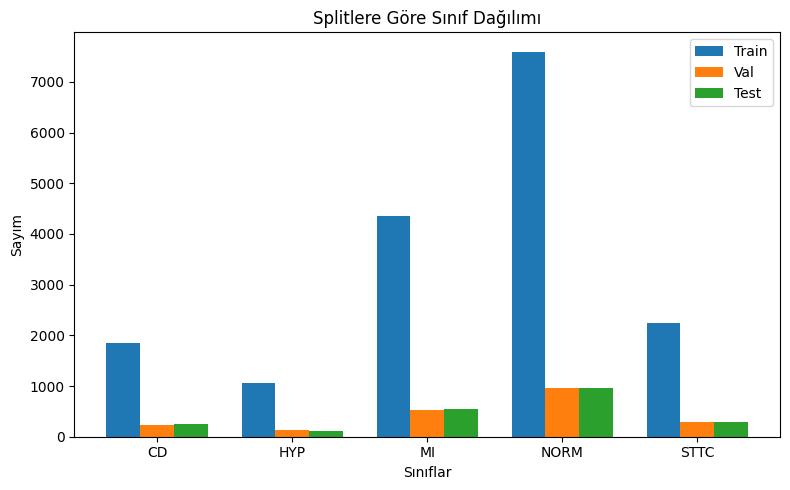


  Class weights (computed from train):
    HYP: 3.233
    CD: 1.855
    STTC: 1.523
    MI: 0.786
    NORM: 0.450


In [21]:
# =============================================================================
# STEP 12: Class Distribution & Weights
# =============================================================================

print("\n" + "="*60)
print("STEP 12: Class Distribution & Weights")
print("="*60)

from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

print("  Class distribution in each split:")
split_counts = {}
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = y.value_counts()
    split_counts[name] = counts
    print(f"\n  {name}:")
    for cls in sorted(counts.index):
        print(f"    {cls}: {counts[cls]} ({counts[cls]/len(y)*100:.1f}%)")

# Plot class distributions
fig, ax = plt.subplots(figsize=(8, 5))
all_classes = sorted(classes)
bar_width = 0.25
x = np.arange(len(all_classes))

for i, (name, counts) in enumerate(split_counts.items()):
    vals = [counts.get(cls, 0) for cls in all_classes]
    ax.bar(x + i * bar_width, vals, width=bar_width, label=name)

ax.set_xlabel("Sınıflar")
ax.set_ylabel("Sayım")
ax.set_title("Splitlere Göre Sınıf Dağılımı")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(all_classes)
ax.legend()
plt.tight_layout()
plt.show()

# Compute class weights from train set only
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("\n  Class weights (computed from train):")
for cls, weight in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"    {cls}: {weight:.3f}")


In [22]:

# =============================================================================
# STEP 13: Save preprocessed data
# =============================================================================

print("\n" + "="*60)
print("STEP 13: Saving Preprocessed Data")
print("="*60)

import os
os.makedirs("../data/processed", exist_ok=True)

# Save as CSV
X_train_final.to_csv("../data/processed/X_train.csv", index=False)
X_val_final.to_csv("../data/processed/X_val.csv", index=False)
X_test_final.to_csv("../data/processed/X_test.csv", index=False)

y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

# Save class weights
pd.DataFrame([class_weight_dict]).to_csv("../data/processed/class_weights.csv", index=False)

# Save feature names
all_features = list(feature_cols) + list(missing_indicator_cols)
pd.DataFrame({"feature": all_features}).to_csv("../data/processed/feature_names.csv", index=False)

print("  Files saved to ../data/processed/")



STEP 13: Saving Preprocessed Data
  Files saved to ../data/processed/


In [23]:

# =============================================================================
# STEP 14: Summary
# =============================================================================

print("\n" + "="*60)
print("PREPROCESSING COMPLETE - SUMMARY")
print("="*60)
print(f"""
Dataset:
  - Total samples: {len(df)}
  - Features: {len(all_features)} ({len(feature_cols)} numeric + {len(missing_indicator_cols)} missing indicators)
  - Classes: {len(classes)} ({', '.join(sorted(classes))})

Splits:
  - Train: {len(X_train_final)} ({len(X_train_final)/len(df)*100:.1f}%)
  - Val:   {len(X_val_final)} ({len(X_val_final)/len(df)*100:.1f}%)
  - Test:  {len(X_test_final)} ({len(X_test_final)/len(df)*100:.1f}%)

Preprocessing Steps:
  1. Removed rows with missing labels (411 rows)
  2. Row-wise missing check (removed rows with >50% missing)
  3. Created BMI feature from height/weight
  4. Created missing indicator features for P-wave related columns
  5. Train/Val/Test split BEFORE imputation (no data leakage)
  6. Median imputation (fitted on train only)
  7. StandardScaler (fitted on train only)
  8. Computed class weights for imbalance handling

Missing Indicators Created:
  {', '.join(missing_indicator_cols)}

Class Weights:
  {', '.join([f'{k}: {v:.2f}' for k, v in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)])}
""")



PREPROCESSING COMPLETE - SUMMARY

Dataset:
  - Total samples: 21388
  - Features: 793 (787 numeric + 6 missing indicators)
  - Classes: 5 (CD, HYP, MI, NORM, STTC)

Splits:
  - Train: 17084 (79.9%)
  - Val:   2146 (10.0%)
  - Test:  2158 (10.1%)

Preprocessing Steps:
  1. Removed rows with missing labels (411 rows)
  2. Row-wise missing check (removed rows with >50% missing)
  3. Created BMI feature from height/weight
  4. Created missing indicator features for P-wave related columns
  5. Train/Val/Test split BEFORE imputation (no data leakage)
  6. Median imputation (fitted on train only)
  7. StandardScaler (fitted on train only)
  8. Computed class weights for imbalance handling

Missing Indicators Created:
  P_On_Global_missing, P_Off_Global_missing, P_Dur_Global_missing, PR_Int_Global_missing, P_AxisFront_Global_missing, HR_Atrial_Global_missing

Class Weights:
  HYP: 3.23, CD: 1.85, STTC: 1.52, MI: 0.79, NORM: 0.45



In [24]:
# tring oversampleing
# =============================================================================
# STEP 12.1 intermediat step: oversample minority classes in training set (critical!)
# =============================================================================
from sklearn.utils import resample, shuffle
print("\n" + "="*60)
print("STEP 12.1: Oversampling Minority Classes in Training Set")
print("="*60)
# Combine X and y for resampling
train_data = pd.concat([X_train_final, y_train.reset_index(drop=True)], axis=1)
max_size = train_data['label'].value_counts().max()
lst = [train_data]
for class_index, group in train_data.groupby('label'):
    lst.append(group.sample(max_size-len(group), replace=True))
train_data_over = pd.concat(lst)
train_data_over = shuffle(train_data_over, random_state=42)
X_train_final = train_data_over.drop('label', axis=1)
y_train = train_data_over['label']
print("  Oversampling complete.")


STEP 12.1: Oversampling Minority Classes in Training Set
  Oversampling complete.


In [25]:
# =============================================================================
# STEP 13: Save preprocessed data
# ============================================================================= 
print("\n" + "="*60)
print("STEP 13: Saving Preprocessed Data After Oversampling")
print("="*60)
import os
os.makedirs("../data/processed", exist_ok=True)
# Save as CSV
X_train_final.to_csv("../data/processed/X_train_oversampled.csv", index=False)
y_train.to_csv("../data/processed/y_train_oversampled.csv", index=False)
print("  Oversampled files saved to ../data/processed/")



STEP 13: Saving Preprocessed Data After Oversampling
  Oversampled files saved to ../data/processed/



STEP 12: Class Distribution & Weights after oversampling
  Class distribution in training set after oversampling:
    CD: 7596 (20.0%)
    HYP: 7596 (20.0%)
    MI: 7596 (20.0%)
    NORM: 7596 (20.0%)
    STTC: 7596 (20.0%)
    CD: 238 (11.1%)
    HYP: 129 (6.0%)
    MI: 535 (24.9%)
    NORM: 955 (44.5%)
    STTC: 289 (13.5%)
    CD: 245 (11.4%)
    HYP: 122 (5.7%)
    MI: 544 (25.2%)
    NORM: 963 (44.6%)
    STTC: 284 (13.2%)


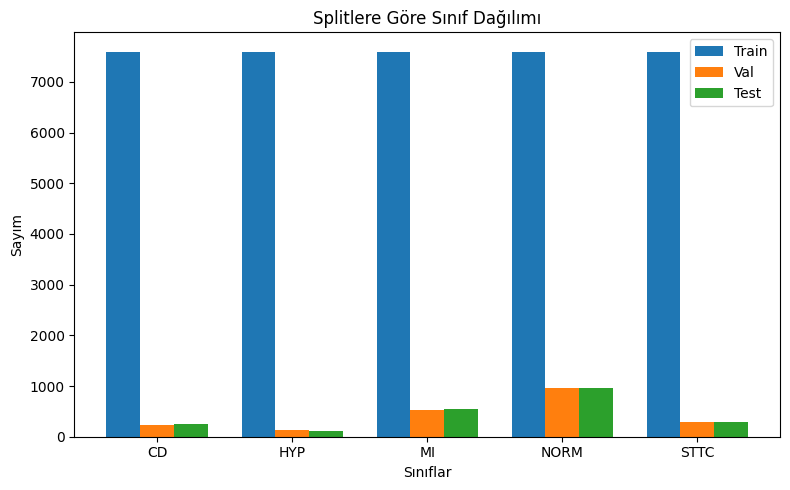


  Class weights (computed from train):
    CD: 1.000
    HYP: 1.000
    MI: 1.000
    NORM: 1.000
    STTC: 1.000


In [27]:
# =============================================================================
# STEP 12: Class Distribution & Weights after oversampling
# =============================================================================
print("\n" + "="*60)
print("STEP 12: Class Distribution & Weights after oversampling")
print("="*60)
from sklearn.utils.class_weight import compute_class_weight
print("  Class distribution in training set after oversampling:")

split_counts = {}
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = y.value_counts()
    split_counts[name] = counts
    for cls in sorted(counts.index):
        print(f"    {cls}: {counts[cls]} ({counts[cls]/len(y)*100:.1f}%)")

# Plot class distributions
fig, ax = plt.subplots(figsize=(8, 5))
all_classes = sorted(classes)
bar_width = 0.25
x = np.arange(len(all_classes))

for i, (name, counts) in enumerate(split_counts.items()):
    vals = [counts.get(cls, 0) for cls in all_classes]
    ax.bar(x + i * bar_width, vals, width=bar_width, label=name)

ax.set_xlabel("Sınıflar")
ax.set_ylabel("Sayım")
ax.set_title("Splitlere Göre Sınıf Dağılımı")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(all_classes)
ax.legend()
plt.tight_layout()
plt.show()

# Compute class weights from train set only
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("\n  Class weights (computed from train):")
for cls, weight in sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"    {cls}: {weight:.3f}")
    
    